In [3]:
import h5py
from pathlib import Path
import numpy as np
import random
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import jpeg4py as jpeg
import scipy
import typing as tp
from numpy.typing import NDArray

import os

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
PATH_TO_spec_1 = Path('../data/spec_1/')
PATH_TO_spec_2 = Path('../data/spec_2/')
PATH_TO_spec_3 = Path('../data/spec_3/')
PATH_TO_spec_4 = Path('../data/spec_4/')
PATH_TO_spec_5 = Path('../data/spec_5/')

# Create visual datasets:

Try several approaches:

1. Spectrogram with windowed Fast Fourier Transform (FFT) with overlap (concatenate in 2 dimension)
2. Spectrogram with windowed Fast Fourier Transform direct (concatenate in 2 dimension)
3. Simple spectrogram from trace concatenation with itself in 2D
4. Simple spectrogram with windowed Gauss approximation of each point in spectra
5. 2D seismic images for each receiver

## Process all data

Create optimized dictionary for each data according to they devices



In [5]:
split_trace_receivers = {}  # x-y-ht split traces according to rec
split_break_time_receivers = {}
split_sample_rate_receivers = {}

path_to_files = Path('../data')
file_num = 0
for hdf5_file in tqdm(list(os.walk(path_to_files))[0][-1]):
    if not hdf5_file.endswith('.hdf5'):
        continue
    data_dict = dict(h5py.File(path_to_files / hdf5_file)['TRACE_DATA/DEFAULT'])

    for trace_i, trace in enumerate(data_dict['data_array']):
        x_y_ht_receiver = (
            file_num,
            data_dict['REC_X'][trace_i][0].astype(np.int16),
            data_dict['REC_Y'][trace_i][0].astype(np.int16),
            data_dict['REC_HT'][trace_i][0].astype(np.int16),
        )
        trace = trace.astype(np.float16)
        if x_y_ht_receiver not in split_trace_receivers:
            split_trace_receivers[x_y_ht_receiver] = trace
            split_break_time_receivers[x_y_ht_receiver] = data_dict['SPARE1'][trace_i][0].astype(np.int16)
            split_sample_rate_receivers[x_y_ht_receiver] = data_dict['SAMP_RATE'][trace_i][0].astype(np.int16)
        else:
            split_trace_receivers[x_y_ht_receiver] = np.vstack(
                (split_trace_receivers[x_y_ht_receiver], trace)
            )
            split_break_time_receivers[x_y_ht_receiver] = np.append(
                split_break_time_receivers[x_y_ht_receiver], data_dict['SPARE1'][trace_i][0].astype(np.int16),
            )
            split_sample_rate_receivers[x_y_ht_receiver] = np.append(
                split_sample_rate_receivers[x_y_ht_receiver], data_dict['SAMP_RATE'][trace_i][0].astype(np.int16),
            )
    file_num += 1


100%|██████████| 4/4 [19:08<00:00, 287.08s/it]


In [8]:
# Overview data
total_percent_of_miss = 0
total_data = 0

for k in split_trace_receivers:
    # print(split_trace_receivers[k].shape)
    total_percent_of_miss += np.sum(
        (split_break_time_receivers[k] == 0) +
         (split_break_time_receivers[k] == -1)
        )
    total_data += split_break_time_receivers[k].shape[0]

print(len(split_trace_receivers))
print(total_data)
print(total_percent_of_miss / total_data * 100)

13113
9831242
37.56022891105722


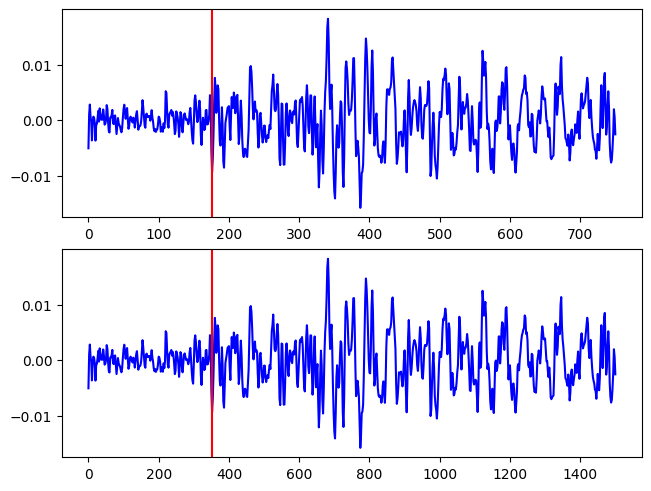

In [46]:
%matplotlib inline
# Test created datastructures

random_receiver = random.choice(list(split_trace_receivers.keys()))
sample_i = random.randrange(split_trace_receivers[random_receiver].shape[0])
sample_count = split_trace_receivers[random_receiver][sample_i].shape[0]

y_data = split_trace_receivers[random_receiver][sample_i]
x_data = range(y_data.shape[0])
x_data_recalc = [i * split_sample_rate_receivers[random_receiver][sample_i].astype(np.int32) / 1000 for i in range(y_data.shape[0])]

fig, axes = plt.subplots(2, 1, constrained_layout=True)

time_break = split_break_time_receivers[random_receiver][sample_i]
time_break = time_break / split_sample_rate_receivers[random_receiver][sample_i] * 1000
axes[0].plot(x_data, y_data, c='b')
axes[0].axvline(x = time_break, color = 'r', label = 'first break')

axes[1].plot(x_data_recalc, y_data, c='b')
axes[1].axvline(x = split_break_time_receivers[random_receiver][sample_i], color = 'r', label = 'first break')

plt.show()

## 1. Spectrogram with windowed Fast Fourier Transform (FFT) with overlap (concatenate in 2 dimension)

Parameters were select empirical de to better visual representation of spectra structure

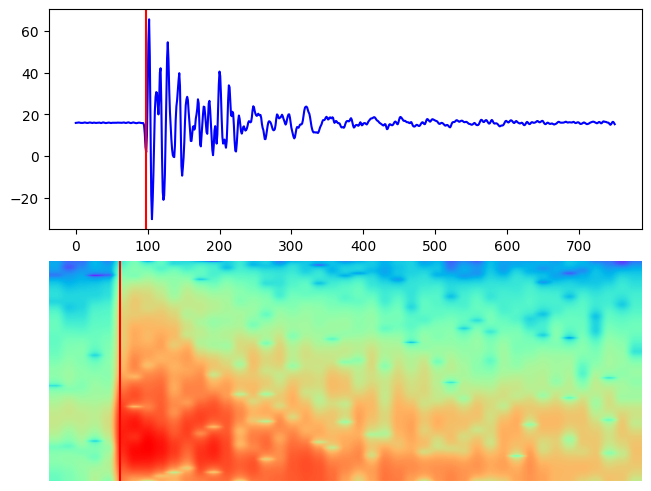

In [44]:
# Check data transformation
fig, (ax_top, ax_spec) = plt.subplots(2, 1, constrained_layout=True)

N = 32
ax_top.plot(x_data, N/2 * y_data + N/2, c='b')
ax_top.axvline(x = time_break, color = 'r', label = 'first break')
Pxx, freqs, bins, cax = ax_spec.specgram(y_data, Fs=6, cmap="rainbow", NFFT=N, noverlap=16, pad_to=N*32)
ax_spec.axvline(x = time_break / (y_data.shape[0] / 120), color = 'r', label = 'first break')
ax_spec.axis('off')
plt.show()

In [117]:
# Test save procedure - good result
fig,ax = plt.subplots(1)
fig.subplots_adjust(left=0,right=1,bottom=0,top=1)
ax.axis('off')
pxx, freqs, bins, im = ax.specgram(y_data, Fs=6, cmap="rainbow", NFFT=N, noverlap=16, pad_to=N*32)
ax.axis('off')
fig.savefig('tests.jpg', dpi=100)


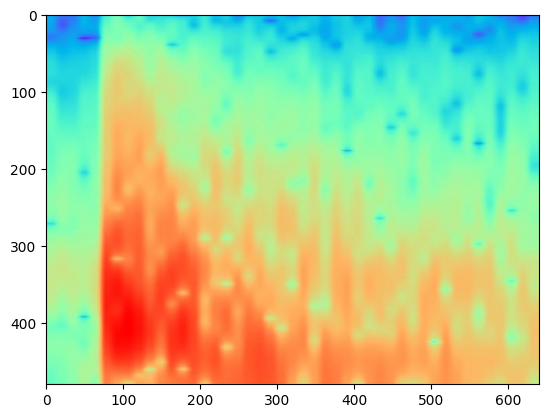

In [85]:
img = jpeg.JPEG('tests.jpg').decode()
img.shape
plt.imshow(img)

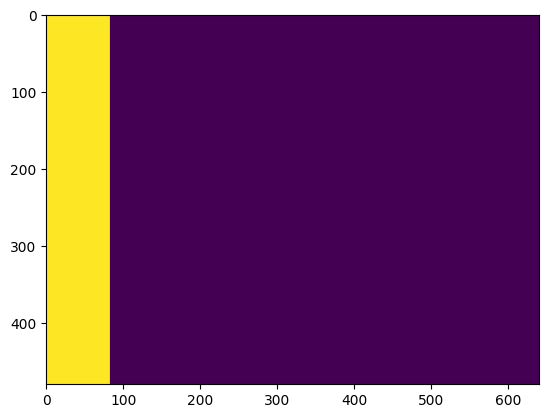

In [86]:
# Check firs break calculation for image - good
feat_time = time_break * (img.shape[1] / y_data.shape[0])
mask = np.zeros(img.shape[:2])
mask[:, :int(feat_time)] = 255

plt.imshow(mask)

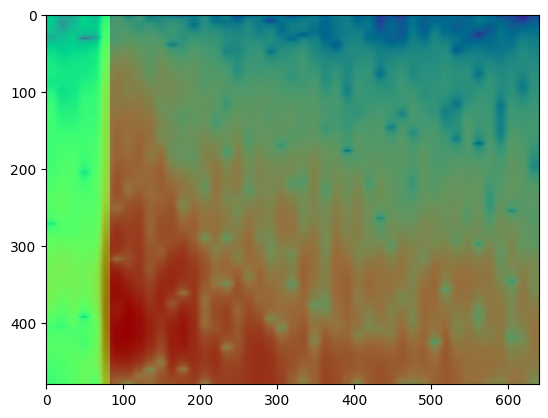

In [87]:
# Total image with mask - valid
green_masks = np.zeros(img.shape, dtype=np.uint8)

green_masks[:,:,0] = 0
green_masks[:,:,1] = mask
green_masks[:,:,2] = 0
img_add = cv2.addWeighted(img, 0.6, green_masks, 0.4, 0)

plt.imshow(img_add)

In [122]:
# Create and save spectra set No 1
%matplotlib  # disable inline output of plots

def save_spec(
        y_data: NDArray[np.float16],
        path: tp.Union[str, Path],
        idx: int,
        time_break: int = 0,
        is_mask: bool = False
) -> None:
    fig,ax = plt.subplots(1)
    fig.subplots_adjust(left=0,right=1,bottom=0,top=1)
    ax.axis('off')
    pxx, freqs, bins, im = ax.specgram(y_data, Fs=6, cmap="rainbow", NFFT=N, noverlap=16, pad_to=N*32)
    ax.axis('off')
    fig.savefig(path / f'{idx}.jpg', dpi=100)
    plt.close('all')

    if is_mask:
        img = jpeg.JPEG(path / f'{idx}.jpg').decode()
        feat_time = time_break * (img.shape[1] / y_data.shape[0])
        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        mask[:, :int(feat_time)] = 1
        cv2.imwrite(
            str(path.parent.absolute() / 'masks' / f'{idx}_{feat_time}-{time_break}-{img.shape[1]}-{y_data.shape[0]}_mask.png'),
            mask
        )


total_known_data = 0
total_unknown_data = 0
data_limit = 100000
print(f"Total receivers: {len(split_break_time_receivers.items())}")
print()

receivers = list(split_trace_receivers.keys())
while total_known_data < data_limit:
    print(f'\tprocess {total_known_data} / {data_limit}', end='\r')
    receiver_index = random.choice(range(len(receivers)))
    select_receiver = receivers[receiver_index]
    traces = split_trace_receivers[select_receiver]
    trace_i = random.choice(range(traces.shape[0]))
    if int(split_break_time_receivers[select_receiver][trace_i]) in [0, -1]:
        save_spec(
            split_trace_receivers[select_receiver][trace_i],
            PATH_TO_spec_1 / 'images_unknown',
            total_unknown_data
        )
        total_unknown_data += 1
    else:
        time_break = split_break_time_receivers[select_receiver][trace_i]
        time_break = time_break / split_sample_rate_receivers[select_receiver][trace_i] * 1000
        save_spec(
            split_trace_receivers[select_receiver][trace_i],
            PATH_TO_spec_1 / 'images',
            total_known_data,
            time_break=time_break,
            is_mask=True
        )
        total_known_data += 1


Using matplotlib backend: agg
Total receivers: 11126



## 2. Spectrogram with windowed Fast Fourier Transform direct (concatenate in 2 dimension)


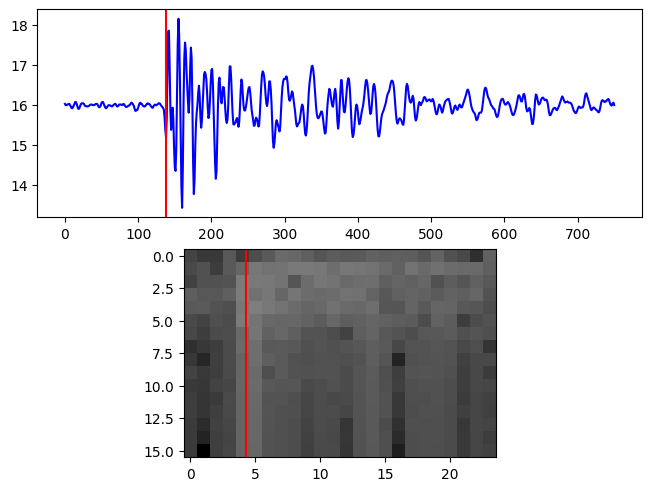

In [157]:
# check data preparation - good
%matplotlib inline

window_size = 32
result_spectra = []
for trace_sample_i in range(0, y_data.shape[0] + 1, window_size):
    x_vector = scipy.fft.fftshift(
        scipy.fft.fft(
            y_data[trace_sample_i : trace_sample_i + window_size], n=window_size
        )
    )[window_size // 2 : window_size]
    Pxx = 10 * np.log10(
        np.real(
            x_vector * np.conj(x_vector)
        )
    )
    result_spectra.append(Pxx)
result_spectra = np.array(result_spectra).T
result_spectra = (
                     (result_spectra / np.max(np.abs(result_spectra))) + 1
                 ) * 127.5
result_image = np.zeros((result_spectra.shape[0], result_spectra.shape[1], 3), dtype=np.uint8)
result_image[:, :, 0] = result_spectra
result_image[:, :, 1] = result_spectra
result_image[:, :, 2] = result_spectra
cv2.imwrite('tests.jpg', result_image)

feat_time = time_break * (result_image.shape[1] / y_data.shape[0])
mask = np.zeros(result_spectra.shape, dtype=np.uint8)
mask[:, :int(feat_time)] = 255

# Spectrogram rendering:
fig, (ax_top, ax_spec) = plt.subplots(2, 1, constrained_layout=True)
ax_top.plot(x_data, N/2 * y_data + N/2, c='b')
ax_top.axvline(x = time_break, color = 'r', label = 'first break')

ax_spec.imshow(result_image)
plt.axvline(x = time_break / N, color = 'r', label = 'first break')

plt.show()

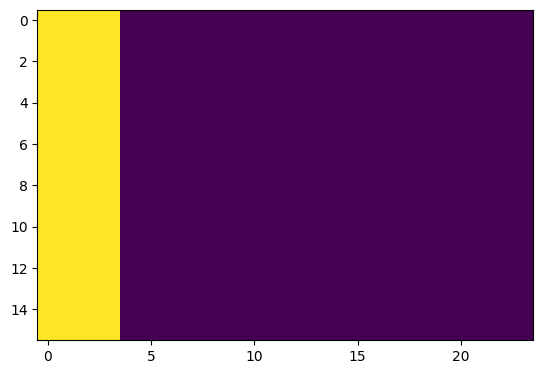

In [158]:
# Check mask - good
plt.imshow(mask)

In [160]:
# Create spectra set No2
%matplotlib


def save_spec(
        trace_data: NDArray[np.float16],
        path: tp.Union[str, Path],
        idx: int,
        time_break: int = 0,
        is_mask: bool = False
) -> None:
    window_size = 32
    result_spectra = []
    for trace_sample_i in range(0, trace_data.shape[0] + 1, window_size):
        x_vector = scipy.fft.fftshift(
            scipy.fft.fft(
                trace_data[trace_sample_i : trace_sample_i + window_size], n=window_size
            )
        )[window_size // 2 : window_size]
        Pxx = 10 * np.log10(
            np.real(
                x_vector * np.conj(x_vector)
            )
        )
        result_spectra.append(Pxx)
    result_spectra = np.array(result_spectra).T
    result_spectra = (
                         (result_spectra / np.max(np.abs(result_spectra))) + 1
                     ) * 127.5
    result_image = np.zeros((result_spectra.shape[0], result_spectra.shape[1], 3), dtype=np.uint8)
    result_image[:, :, 0] = result_spectra
    result_image[:, :, 1] = result_spectra
    result_image[:, :, 2] = result_spectra

    cv2.imwrite(str(path / f'{idx}.jpg'), result_image)
    if is_mask:
        feat_time = time_break * (result_image.shape[1] / trace_data.shape[0])
        mask = np.zeros(result_spectra.shape, dtype=np.uint8)
        mask[:, :int(feat_time)] = 1
        cv2.imwrite(
            str(path.parent.absolute() / 'masks' / f'{idx}_{feat_time}-{time_break}-{result_image.shape[1]}-{trace_data.shape[0]}_mask.png'),
            mask
        )


total_known_data = 0
total_unknown_data = 0
data_limit = 100000
print(f"Total receivers: {len(split_break_time_receivers.items())}")
print()

receivers = list(split_trace_receivers.keys())
while total_known_data < data_limit:
    print(f'\tprocess {total_known_data} / {data_limit}', end='\r')
    receiver_index = random.choice(range(len(receivers)))
    select_receiver = receivers[receiver_index]
    traces = split_trace_receivers[select_receiver]
    trace_i = random.choice(range(traces.shape[0]))
    if int(split_break_time_receivers[select_receiver][trace_i]) in [0, -1]:
        save_spec(
            split_trace_receivers[select_receiver][trace_i],
            PATH_TO_spec_2 / 'images_unknown',
            total_unknown_data
        )
        total_unknown_data += 1
    else:
        time_break = split_break_time_receivers[select_receiver][trace_i]
        time_break = time_break / split_sample_rate_receivers[select_receiver][trace_i] * 1000
        save_spec(
            split_trace_receivers[select_receiver][trace_i],
            PATH_TO_spec_2 / 'images',
            total_known_data,
            time_break=time_break,
            is_mask=True
        )
        total_known_data += 1


Using matplotlib backend: agg
Total receivers: 11126



## 3. Simple spectrogram from trace concatenation with itself in 2D

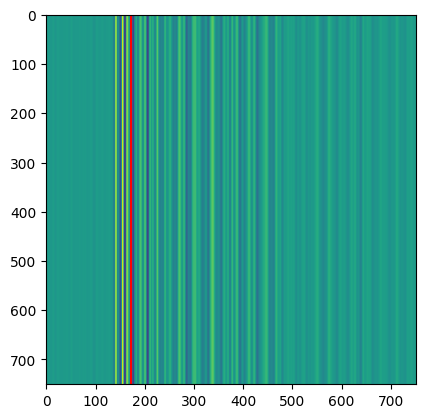

In [175]:
# Check data build - good
%matplotlib inline

xv, yv = np.meshgrid(y_data, y_data)
spectra_2d = np.transpose(yv)
spectra_2d = (
    (spectra_2d / np.max(np.abs(spectra_2d))) + 1
) * 127.5
result_image = np.zeros((spectra_2d.shape[0], spectra_2d.shape[1], 3), dtype=np.uint8)
result_image[:, :, 0] = spectra_2d
result_image[:, :, 1] = spectra_2d
result_image[:, :, 2] = spectra_2d

mask = np.zeros(spectra_2d.shape, dtype=np.uint8)
mask[:, :int(time_break)] = 255

plt.imshow(spectra_2d)
plt.axvline(x = time_break, color = 'r', label = 'first break')
plt.show()

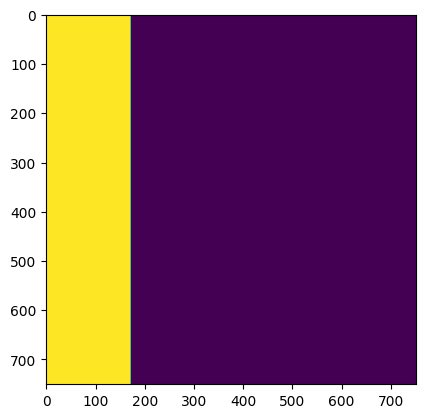

In [164]:
# check mask - good
plt.imshow(mask)

In [177]:
# Create spectra set No 3
%matplotlib


def save_spec(
        trace_data: NDArray[np.float16],
        path: tp.Union[str, Path],
        idx: int,
        time_break: int = 0,
        is_mask: bool = False
) -> None:
    _, yv = np.meshgrid(trace_data, trace_data)
    spectra_2d = np.transpose(yv)
    spectra_2d = (
                         (spectra_2d / np.max(np.abs(spectra_2d))) + 1
                 ) * 127.5
    result_image = np.zeros((spectra_2d.shape[0], spectra_2d.shape[1], 3), dtype=np.uint8)
    result_image[:, :, 0] = spectra_2d
    result_image[:, :, 1] = spectra_2d
    result_image[:, :, 2] = spectra_2d
    cv2.imwrite(str(path / f'{idx}.jpg'), result_image)
    if is_mask:
        mask = np.zeros(spectra_2d.shape, dtype=np.uint8)
        mask[:, :int(time_break)] = 1
        cv2.imwrite(
            str(path.parent.absolute() / 'masks' / f'{idx}_{feat_time}-{time_break}-{result_image.shape[1]}-{trace_data.shape[0]}_mask.png'),
            mask
        )


total_known_data = 0
total_unknown_data = 0
data_limit = 100000
print(f"Total receivers: {len(split_break_time_receivers.items())}")
print()

receivers = list(split_trace_receivers.keys())
while total_known_data < data_limit:
    print(f'\tprocess {total_known_data} / {data_limit}', end='\r')
    receiver_index = random.choice(range(len(receivers)))
    select_receiver = receivers[receiver_index]
    traces = split_trace_receivers[select_receiver]
    trace_i = random.choice(range(traces.shape[0]))
    if int(split_break_time_receivers[select_receiver][trace_i]) in [0, -1]:
        save_spec(
            split_trace_receivers[select_receiver][trace_i],
            PATH_TO_spec_3 / 'images_unknown',
            total_unknown_data
        )
        total_unknown_data += 1
    else:
        time_break = split_break_time_receivers[select_receiver][trace_i]
        time_break = time_break / split_sample_rate_receivers[select_receiver][trace_i] * 1000
        save_spec(
            split_trace_receivers[select_receiver][trace_i],
            PATH_TO_spec_3 / 'images',
            total_known_data,
            time_break=time_break,
            is_mask=True
        )
        total_known_data += 1


Using matplotlib backend: agg
Total receivers: 11126



## 4. Simple spectrogram with windowed Gauss approximation of each point in spectra

(256, 751)


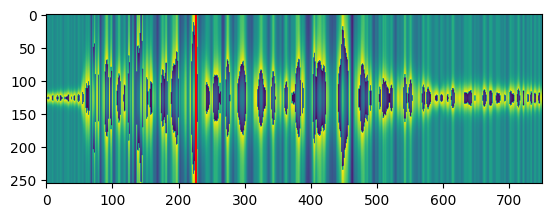

In [15]:
# Check data build - good
%matplotlib inline


def gauss_array(
        mu: float,
        std: float,
        range_N: int
) -> NDArray[np.float32]:
    x_gauss = np.linspace(int(-range_N / 2), int(range_N / 2), range_N)
    y_gauss = np.exp(-(x_gauss - mu)**2 / (2 * std**2)) / (std * np.sqrt(2 * np.pi))
    return y_gauss.astype(np.float32)

y_data_filtered = y_data.copy()
y_data_filtered = ((y_data_filtered / np.max(np.abs(y_data_filtered))) + 1) * 127.5
y_data_filtered[y_data_filtered < np.mean(y_data)] = np.mean(y_data)

N = 32
range_gauss_N = 256
spec_data = np.zeros((range_gauss_N, y_data.shape[0]), np.uint8)

for idx in range(y_data_filtered.shape[0]):
    start = idx - N // 2
    stop = idx + N // 2
    if start < 0:
        start = 0
    if stop > y_data_filtered.shape[0]:
        stop = y_data_filtered.shape[0]
    window_sample = y_data_filtered[start:stop]
    std = np.std(window_sample.astype(np.float32))
    mu = 0  # np.mean(window_sample).astype(np.float32)
    gauss_sample = gauss_array(mu, std, range_gauss_N)
    gauss_sample = (gauss_sample / np.max(np.abs(gauss_sample)) + 1) * y_data_filtered[idx]
    spec_data[:, idx] = gauss_sample.astype(np.uint8)

print(spec_data.shape)

result_image = np.zeros((spec_data.shape[0], spec_data.shape[1], 3), dtype=np.uint8)
result_image[:, :, 0] = spec_data
result_image[:, :, 1] = spec_data
result_image[:, :, 2] = spec_data

mask = np.zeros(spec_data.shape, dtype=np.uint8)
mask[:, :int(time_break)] = 255

plt.imshow(
    result_image[:, :, 0],
)
plt.axvline(x = time_break, color = 'r', label = 'first break')
plt.show()

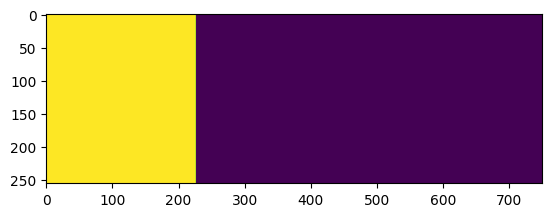

In [17]:
# Check mask - good
plt.imshow(mask)

In [26]:
# Build spectra set No 4
%matplotlib


def save_spec(
        trace_data: NDArray[np.float16],
        path: tp.Union[str, Path],
        img_idx: int,
        time_break: int = 0,
        is_mask: bool = False
) -> None:
    trace_data = ((trace_data / np.max(np.abs(trace_data))) + 1) * 127.5
    trace_data[trace_data < np.mean(trace_data)] = np.mean(trace_data)

    N = 32
    range_gauss_N = 256
    spec_data = np.zeros((range_gauss_N, trace_data.shape[0]), np.uint8)

    for idx in range(trace_data.shape[0]):
        start = idx - N // 2
        stop = idx + N // 2
        if start < 0:
            start = 0
        if stop > trace_data.shape[0]:
            stop = trace_data.shape[0]
        window_sample = trace_data[start:stop]
        std = np.std(window_sample.astype(np.float32))
        mu = 0  # np.mean(window_sample).astype(np.float32)
        gauss_sample = gauss_array(mu, std, range_gauss_N)
        gauss_sample = (gauss_sample / np.max(np.abs(gauss_sample)) + 1) * trace_data[idx]
        spec_data[:, idx] = gauss_sample.astype(np.uint8)

    result_image = np.zeros((spec_data.shape[0], spec_data.shape[1], 3), dtype=np.uint8)
    result_image[:, :, 0] = spec_data
    result_image[:, :, 1] = spec_data
    result_image[:, :, 2] = spec_data
    cv2.imwrite(str(path / f'{img_idx}.jpg'), result_image)
    if is_mask:
        mask = np.zeros(spec_data.shape, dtype=np.uint8)
        mask[:, :int(time_break)] = 1
        cv2.imwrite(
            str(path.parent.absolute() / 'masks' / f'{img_idx}_{time_break}_mask.png'),
            mask
        )


total_known_data = 0
total_unknown_data = 0
data_limit = 100000
print(f"Total receivers: {len(split_break_time_receivers.items())}")
print()

receivers = list(split_trace_receivers.keys())
while total_known_data < data_limit:
    print(f'\tprocess {total_known_data} / {data_limit}', end='\r')
    receiver_index = random.choice(range(len(receivers)))
    select_receiver = receivers[receiver_index]
    traces = split_trace_receivers[select_receiver]
    trace_i = random.choice(range(traces.shape[0]))
    if int(split_break_time_receivers[select_receiver][trace_i]) in [0, -1]:
        save_spec(
            split_trace_receivers[select_receiver][trace_i],
            PATH_TO_spec_4 / 'images_unknown',
            total_unknown_data
        )
        total_unknown_data += 1
    else:
        time_break = split_break_time_receivers[select_receiver][trace_i]
        time_break = time_break / split_sample_rate_receivers[select_receiver][trace_i] * 1000
        save_spec(
            split_trace_receivers[select_receiver][trace_i],
            PATH_TO_spec_4 / 'images',
            total_known_data,
            time_break=time_break,
            is_mask=True
        )
        total_known_data += 1

Using matplotlib backend: agg
Total receivers: 11126



## 5. 2D seismic images for each receiver

(751, 266) (751, 266, 3)


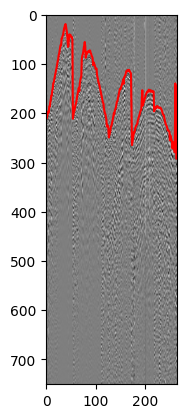

In [217]:
# Check data build - good
%matplotlib inline


def my_norm(x: NDArray[np.float16]) -> NDArray[np.float16]:
    return ((x / np.max(np.abs(x))) + 1) * 127.5


receivers = list(split_trace_receivers.keys())
receiver_index = random.choice(range(len(receivers)))
select_receiver = receivers[receiver_index]

y_data_filtered = split_trace_receivers[select_receiver].copy()
y_data_filtered = np.transpose(np.apply_along_axis(my_norm, 1, y_data_filtered))

result_image = np.zeros((y_data_filtered.shape[0], y_data_filtered.shape[1], 3), dtype=np.uint8)
result_image[:, :, 0] = y_data_filtered
result_image[:, :, 1] = y_data_filtered
result_image[:, :, 2] = y_data_filtered

print(y_data_filtered.shape, result_image.shape)
plt.imshow(result_image)

# Fix missing break time
x_breaks = range(split_break_time_receivers[select_receiver].shape[0])
y_breaks = []  # replace 1st brackes 0 and -1 for average between neighbors
for t_break_i, t_break in enumerate(split_break_time_receivers[select_receiver]):
    if int(t_break) in [0, -1] and t_break_i + 1 < split_break_time_receivers[select_receiver].shape[0]:
        t_break = np.mean((
            int(split_break_time_receivers[select_receiver][t_break_i-1]),
            int(split_break_time_receivers[select_receiver][t_break_i+1])
        ))
    elif int(t_break) in [0, -1]:
        t_break = int(split_break_time_receivers[select_receiver][t_break_i-1])
    t_break = t_break / split_sample_rate_receivers[select_receiver][t_break_i] * 1000
    y_breaks.append(t_break)
plt.plot(x_breaks, y_breaks, color = 'r')
plt.show()

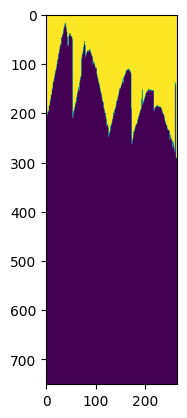

In [220]:
# Check masks - good
mask = np.zeros(y_data_filtered.shape, np.uint8)
for break_point_i, break_point in enumerate(y_breaks):
    mask[:int(break_point), break_point_i] = 255
plt.imshow(mask)

In [223]:
%matplotlib


def my_norm(input_aray: NDArray[np.float16]) -> NDArray[np.float16]:
        return ((input_aray / np.max(np.abs(input_aray))) + 1) * 127.5

def save_spec(
        traces_data: NDArray[np.float16],
        time_breaks: NDArray[np.int16],
        rate_receivers: NDArray[np.int16],
        path: tp.Union[str, Path],
        idx: int,
        is_mask: bool = False
) -> None:
    traces_data = np.transpose(np.apply_along_axis(my_norm, 1, traces_data))
    result_image = np.zeros((traces_data.shape[0], traces_data.shape[1], 3), dtype=np.uint8)
    result_image[:, :, 0] = traces_data
    result_image[:, :, 1] = traces_data
    result_image[:, :, 2] = traces_data
    cv2.imwrite(str(path / f'{idx}.jpg'), result_image)
    if is_mask:
        # Fix missing break time
        y_breaks = []  # replace 1st brackes 0 and -1 for average between neighbors
        for t_break_i, t_break in enumerate(time_breaks):
            if int(t_break) in [0, -1] and t_break_i + 1 < time_breaks.shape[0]:
                t_break = np.mean((
                    int(time_breaks[t_break_i-1]),
                    int(time_breaks[t_break_i+1])
                ))
            elif int(t_break) in [0, -1]:
                t_break = int(time_breaks[t_break_i-1])
            t_break = t_break / rate_receivers[t_break_i] * 1000
            y_breaks.append(t_break)
        mask = np.zeros(traces_data.shape, np.uint8)
        for break_point_i, break_point in enumerate(y_breaks):
            mask[:int(break_point), break_point_i] = 1
        cv2.imwrite(
            str(path.parent.absolute() / 'masks' / f'{idx}_{feat_time}-{time_break}-{result_image.shape[1]}-{traces_data.shape[0]}_mask.png'),
            mask
        )


print(f"Total receivers: {len(split_break_time_receivers.items())}")
print()

total_known_data = 0
for receiver in tqdm(split_trace_receivers):
    if np.sum(split_break_time_receivers[receiver] > 0) < split_break_time_receivers[receiver].shape[0] / 3:
        continue
    save_spec(
        split_trace_receivers[receiver],
        split_break_time_receivers[receiver],
        split_sample_rate_receivers[receiver],
        PATH_TO_spec_5 / 'images',
        total_known_data,
        is_mask=True
    )
    total_known_data += 1

Using matplotlib backend: agg
Total receivers: 11126



100%|██████████| 11126/11126 [05:38<00:00, 32.91it/s]
